감독관 ai가 팀원 ai에게 일을 분배해서 일을 해결하도록 만듬

In [1]:
!pip install langchain langchain_openai langsmith pandas langchain_experimental matplotlib langgraph langchain_core duckduckgo-search langchain-community

In [2]:
import os
from uuid import uuid4

In [3]:
unique_id = uuid4().hex[0:8]
os.environ['LANGCHAIN_TRACING_V2'] = 'ture'
os.environ["LANGCHAIN_PROJECT"] = f'Basic Agent Supercisor  {unique_id}'
os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGCHAIN_API_KEY'] = ''
os.environ['OPENAI_API_KEY'] = ''
os.environ['TAVILY_API_KEY'] = ''

In [5]:
unique_id

'f1322d28'

create tools

In [6]:
from typing import Annotated
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_experimental.tools import PythonREPLTool

In [7]:
tavily_tool = TavilySearchResults(max_results=5)
python_repl_tool = PythonREPLTool()

C:\Users\compro\AppData\Local\Temp\ipykernel_29116\1206960268.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(max_results=5)


hepler utilities
그래프에서 노드를 생성하는데 사용할 헬퍼 함수. 이 함수는 에이전트 응답을 사람의 메세지로 변환해주는 작업수행. 그래프의 글로벌 상태에 추가하는 방법이기 때문에 중요

In [8]:
from langchain_core.messages import HumanMessage

In [9]:
def agent_node(state, agent, name):
    result = agent.invoke(state)
    return {'messages': [HumanMessage(content=result['messages'][-1].content, name=name)]}

create agent supervisor

함수 호출을 사용하여 다음 작업자 노드를 선택, 처리 완료 수행

In [10]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import ChatOpenAI
from enum import Enum
from pydantic import BaseModel
from typing import Literal

In [11]:
members = ['Researcher', 'Coder']
system_prompt = (
    'You are a supervisor tasked with managing a conersation between the'
    'following workers: {members}. Given the following user request,'
    'respond with the worker to act next. Each worker will perform a'
    'task and respond with their results and status. When finished'
    'respond with FINISH.'
)

options = ['FINISH'] + members
class routeResponse(BaseModel):
    next: Literal['FINISH', 'Researcher', 'Coder']

prompt = ChatPromptTemplate.from_messages(
    [
        ('system', system_prompt),
        MessagesPlaceholder(variable_name='messages'),
        (
            'system',
            'Given the conversation above, who should act next?'
            'Or should we FINISH? Select one of: {options}',
        ),
    ]
).partial(options=str(options), members=', '.join(members))

llm = ChatOpenAI(model='gpt-4o')

def supervisor_agent(state):
    supervisor_chain = (
        prompt | llm.with_structured_output(routeResponse)
    )
    return supervisor_chain.invoke(state)

construct graph

In [12]:
import functools
import operator
from typing import Sequence, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import create_react_agent

In [15]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    next: str

research_agent = create_react_agent(llm, tools=[tavily_tool])
research_node = functools.partial(agent_node, agent=research_agent, name='Researcher')

code_agent = create_react_agent(llm, tools=[python_repl_tool])
code_node = functools.partial(agent_node, agent=code_agent, name='Coder')

workflow = StateGraph(AgentState)
workflow.add_node('Researcher', research_node)
workflow.add_node('Coder', code_node)
workflow.add_node('supervisor', supervisor_agent)

C:\Users\compro\AppData\Local\Temp\ipykernel_29116\1457584718.py:5: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(llm, tools=[tavily_tool])
C:\Users\compro\AppData\Local\Temp\ipykernel_29116\1457584718.py:8: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  code_agent = create_react_agent(llm, tools=[python_repl_tool])


In [16]:
for member in members:
    workflow.add_edge(member, 'supervisor')
conditional_map = {k: k for k in members}
conditional_map['FINISH'] = END
workflow.add_conditional_edges('supervisor', lambda x:x['next'], conditional_map)
workflow.add_edge(START, 'supervisor')

graph = workflow.compile()

In [18]:
from IPython.display import Image, display

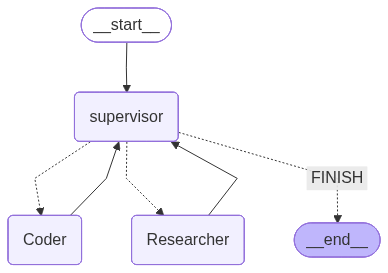

In [19]:
try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

invoke the team

In [20]:
for s in graph.stream(
    {
        'messages': [HumanMessage(content='Code hello world and print it to the terminal')]
    }
):
    if '__end__' not in s:
        print(s)
        print('----')

{'supervisor': {'next': 'Coder'}}
----


Python REPL can execute arbitrary code. Use with caution.


{'Coder': {'messages': [HumanMessage(content='Here is your "Hello, world!" program printed to the terminal:\n\n```\nHello, world!\n```', additional_kwargs={}, response_metadata={}, name='Coder')]}}
----
{'supervisor': {'next': 'Coder'}}
----
{'Coder': {'messages': [HumanMessage(content='The output of the code is:\n\n```\nHello, world!\n```\n\nThis is printed to the terminal using the `print` function in Python.', additional_kwargs={}, response_metadata={}, name='Coder')]}}
----
{'supervisor': {'next': 'FINISH'}}
----


In [21]:
for s in graph.stream(
    {
        'messages': [HumanMessage(content='Write a brief research report on pikas.')]
    },
    {'recursion_limit': 10}
):
    if '__end__'not in s:
        print(s)
        print('----')

{'supervisor': {'next': 'Researcher'}}
----
{'Researcher': {'messages': [HumanMessage(content='# Research Report on Pikas\n\n## Introduction\nPikas are small, herbivorous mammals belonging to the family Ochotonidae, which is closely related to rabbits and hares. They are typically found in cold climates, usually in mountainous regions of North America, Asia, and Eastern Europe. Known for their distinctive calls and energetic behaviors, pikas are an integral part of their ecological systems.\n\n## Physical Characteristics\nPikas are characterized by their small, round bodies, short limbs, and no visible tail. They typically weigh about 120 to 350 grams and are around 15 to 23 centimeters long. Their fur color ranges from brown to grey, aiding in camouflage within their rocky habitats.\n\n## Habitat\nPikas primarily inhabit talus fields in mountainous regions, where they can easily hide from predators in rock crevices. They are found in the steppes of Asia, North America\'s mountains lik

In [22]:
for s in graph.stream(
    {"messages": [HumanMessage(content="사막여우에 대한 간략한 리포트를 한글로 작성해줘.")]},
    {"recursion_limit": 10},
):
    if "__end__" not in s:
        print(s)
        print("----")

{'supervisor': {'next': 'Researcher'}}
----
{'Researcher': {'messages': [HumanMessage(content="사막여우(학명: Vulpes zerda)는 북아프리카 및 아라비아반도에서 주로 서식하는 작은 여우의 한 종류입니다. 사막여우는 특히 큰 귀로 유명한데, 이는 체온 조절과 사막 환경에서의 소리 탐지를 위한 기능을 합니다.\n\n### 특징\n- **크기 및 외모**: 몸길이는 약 24~41cm, 꼬리는 18~30cm 정도이며, 몸무게는 약 0.8~1.5kg로 작은 편입니다. 털은 길고 부드러우며, 사막의 낮은 온도를 견디기 적합합니다.\n- **귀**: 10~15cm의 큰 귀는 고열방출과 청각을 위해 발달했습니다.\n- **서식지**: 주로 사막 및 반사막 지역에서 발견되며, 주로 단독 또는 작은 가족단위로 활동합니다.\n\n### 생태와 행동\n- **식성**: 잡식성으로, 주로 곤충, 작은 포유류, 새, 알, 그리고 식물을 먹습니다. 물 섭취가 제한적인 환경에 적응하여 체내 수분을 효율적으로 보존합니다.\n- **번식**: 짝짓기는 일반적으로 1월에 이루어지며, 임신 기간은 약 50일입니다. 한 번에 2~5마리의 새끼를 낳습니다.\n- **커뮤니케이션**: 고주파 소리를 이용한 의사소통이 특징으로, 이는 포식자로부터 자신을 보호하거나 무리를 지을 때 중요합니다.\n\n### 보존 상태\n사막여우는 IUCN 적색목록에서 '관심필요' 등급으로 분류되어 있으며, 주로 서식지 파괴와 밀렵이 주요 위협 요소입니다. 그러나 사막여우는 비교적 넓은 지역에 분포하고 있어 큰 멸종 위기는 아닌 상태입니다.\n\n사막여우는 그 독특한 생김새와 생태적 특성으로 인해 인간에게 많은 흥미를 불러일으키고 있으며, 일부 지역에서는 애완동물로도 인기를 끌고 있습니다.", additional_kwargs={}, response_metadata={}, name='Researcher')]}}
----
{'supervisor'